# Mental Health Sentiment Classification — Classical Machine Learning Pipeline

**Project Type:** Natural Language Processing (NLP)

**Notebook Purpose:** Classical Machine Learning Pipeline for Multi-Class Mental Health Text Classification

---

## Objective

This notebook implements the complete **classical machine learning pipeline** for multi-class mental health sentiment classification.

Using the cleaned and preprocessed dataset, textual statements are transformed into numerical **TF-IDF** feature vectors and evaluated using several supervised machine learning algorithms.

The primary objectives of this notebook are to:

- Load the processed mental health sentiment dataset.
- Prepare training and testing datasets.
- Convert text into TF-IDF feature representations.
- Train and evaluate multiple classical machine learning models.
- Compare model performance using comprehensive evaluation metrics.
- Identify the most effective baseline model.
- Optimize the best-performing model through hyperparameter tuning.
- Save the trained artifacts for deployment and future inference.

The resulting machine learning models establish strong baseline performance that will later be compared with deep learning architectures and transformer-based models.

# 1. Configure Project Paths

Only the directories required for the classical machine learning pipeline are
initialized in this notebook.

The processed dataset is loaded from the processed data directory, while the
trained models, vectorizers, evaluation results, and generated figures are
stored in their corresponding project directories.

In [36]:
from pathlib import Path

try:

    from google.colab import drive

    drive.mount("/content/drive")

    BASE_DIR = Path("/content/drive/MyDrive/Mental_Health_Classification")

except:

    print("Running outside Google Colab...")

    BASE_DIR = Path.cwd()

PROJECT_DIR = BASE_DIR

DATA_DIR = PROJECT_DIR / "data"

PROCESSED_DATA_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"

VECTORIZERS_DIR = PROJECT_DIR / "vectorizers"

TOKENIZERS_DIR = PROJECT_DIR / "tokenizers"

RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR = PROJECT_DIR / "figures"

ENCODERS_DIR = PROJECT_DIR / "encoders"

for directory in [

    PROCESSED_DATA_DIR,

    MODELS_DIR,

    VECTORIZERS_DIR,

    TOKENIZERS_DIR,

    RESULTS_DIR,

    FIGURES_DIR

]:

    directory.mkdir(

        parents=True,

        exist_ok=True

    )

print("Project directories are ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directories are ready.


# 2. Load the Processed Dataset

The processed dataset generated during the data preparation stage is loaded.

This ensures that all machine learning experiments use the exact same cleaned
and standardized dataset.

In [2]:
import pandas as pd

DATASET_PATH = PROCESSED_DATA_DIR / "preprocessed_data.csv"

df = pd.read_csv(

    DATASET_PATH

)

print(df.shape)

df.head()

(50029, 7)


,id,statement,clean_statement,processed_statement,status,char_len,word_len
0,0,oh my gosh,oh my gosh,oh my gosh,Anxiety,10,3
1,1,"trouble sleeping, confused mind, restless hear...","trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,Anxiety,64,10
2,2,"All wrong, back off dear, forward doubt. Stay ...","All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...,Anxiety,78,14
3,3,I've shifted my focus to something else but I'...,I've shifted my focus to something else but I'...,ive shifted my focus to something else but im ...,Anxiety,61,11
4,4,"I'm restless and restless, it's been a month n...","I'm restless and restless, it's been a month n...",im restless and restless it been a month now b...,Anxiety,72,14


# 3. Verify the Processed Dataset

A quick verification is performed to ensure that the processed dataset has been
loaded successfully before starting the machine learning pipeline.

In [3]:
print(df.shape)

print()

print(df["status"].value_counts())

print()

df.head()

(50029, 7)

status
Normal        15925
Depression    15081
Suicidal      10629
Anxiety        3605
Bipolar        2501
Stress         2288
Name: count, dtype: int64



,id,statement,clean_statement,processed_statement,status,char_len,word_len
0,0,oh my gosh,oh my gosh,oh my gosh,Anxiety,10,3
1,1,"trouble sleeping, confused mind, restless hear...","trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,Anxiety,64,10
2,2,"All wrong, back off dear, forward doubt. Stay ...","All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...,Anxiety,78,14
3,3,I've shifted my focus to something else but I'...,I've shifted my focus to something else but I'...,ive shifted my focus to something else but im ...,Anxiety,61,11
4,4,"I'm restless and restless, it's been a month n...","I'm restless and restless, it's been a month n...",im restless and restless it been a month now b...,Anxiety,72,14


# ==============================================================================
# Feature Selection & Data Splitting


After completing the data cleaning and exploratory analysis phases, the next
step is to prepare the dataset for machine learning.

In this section, we define the input feature and target variable, then split
the dataset into training and testing subsets. This ensures that model
performance is evaluated on unseen data, providing a reliable estimate of its
generalization capability.

## 1. Select Features and Target

The cleaned text (`processed_statement`) is used as the primary input feature,
while the `status` column serves as the target label.

Although additional numerical features such as text length are available, they
are intentionally excluded from the baseline experiments to evaluate the
predictive power of textual information alone.

In [4]:
# Select input feature and target variable

X = df["processed_statement"]
y = df["status"]

print(f"Number of samples: {len(X):,}")
print(f"Number of classes: {y.nunique()}")

print("\nTarget Classes:")
print(sorted(y.unique()))

Number of samples: 50,029
Number of classes: 6

Target Classes:
['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Stress', 'Suicidal']


### Why were `char_len` and `word_len` excluded?

The objective of the baseline models is to evaluate how well the textual
content alone can classify mental health categories.

Additional numerical features may improve performance, but they are reserved
for future experiments to ensure a fair assessment of text-based
representations.

## 2. Train-Test Split

Before training any model, the dataset is divided into training and testing
sets.

The training set is used to learn patterns from the data, while the testing
set remains completely unseen during training and is used only for final
evaluation.

In [5]:
# Split the dataset into training and testing subsets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))

Training samples : 40023
Testing samples  : 10006


### Why Stratified Splitting?

The dataset contains multiple sentiment classes with different sample counts.

Using `stratify=y` preserves the original class distribution in both the
training and testing sets, reducing sampling bias and producing a more
reliable evaluation.

## 3. Data Leakage Check

Before feature extraction, we verify that the training and testing sets are
completely separated.

This step helps prevent data leakage, ensuring that no information from the
test set is accidentally used during model training.

In [6]:
# Verify that there is no overlap between train and test sets

train_samples = set(X_train)
test_samples = set(X_test)

overlap = train_samples.intersection(test_samples)

print(f"Overlapping samples: {len(overlap)}")

Overlapping samples: 0


In [7]:
print(df["clean_statement"].duplicated().sum())

print(df["processed_statement"].duplicated().sum())

0
0


# ==============================================================================
# Text Vectorization

Machine learning algorithms cannot process raw text directly. Therefore, the
cleaned textual data must be transformed into a numerical representation before
model training.

In this project, TF-IDF (Term Frequency–Inverse Document Frequency) is selected
as the baseline feature extraction technique because it captures the importance
of words while reducing the influence of commonly occurring terms.

This representation is computationally efficient and has consistently shown
strong performance in traditional NLP classification tasks.

## Why TF-IDF?

Several techniques can be used to convert text into numerical features.

- **One-Hot Encoding** produces extremely sparse vectors and ignores word frequency.
- **Bag of Words** considers word frequency but treats all words equally.
- **TF-IDF** assigns higher importance to informative words while reducing the
  impact of very common words.
- **Word Embeddings** (e.g., Word2Vec, FastText) capture semantic relationships
  but are typically more suitable for deep learning models.
- **Contextual Embeddings** (e.g., BERT) provide the richest representation but
  require significantly more computational resources.

Since the objective is to establish strong baseline machine learning models,
TF-IDF offers an excellent balance between simplicity, efficiency, and
classification performance.

In [8]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

## TF-IDF Configuration

The vectorizer is configured using both unigrams and bigrams.

- **Unigrams** capture individual words.
- **Bigrams** capture short phrases that may carry stronger sentiment than
  individual words alone.

Additionally, extremely rare terms are removed to reduce noise and improve
generalization.

In [9]:
# Initialize the TF-IDF vectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

### TF-IDF Parameter Selection

The TF-IDF vectorizer was configured using carefully selected parameters to
balance feature richness, computational efficiency, and model generalization.

| Parameter | Selected Value | Rationale |
|-----------|---------------|-----------|
| **max_features** | `10000` | Limits the vocabulary size to the most informative terms, reducing memory usage and computational complexity while preventing an excessively high-dimensional feature space. |
| **ngram_range** | `(1, 2)` | Includes both unigrams and bigrams, allowing the model to capture individual words as well as short phrases that often convey stronger sentiment. |
| **min_df** | `2` | Removes extremely rare words that appear in only one document, helping reduce noise and improve generalization. |
| **max_df** | `0.95` | Excludes overly frequent terms that appear in almost every document, as they usually provide little discriminative information. |
| **sublinear_tf** | `True` | Applies logarithmic scaling to term frequencies, reducing the dominance of highly repeated words and improving feature representation for text classification tasks. |

## Fit the Vectorizer

The TF-IDF vocabulary is learned **only from the training data**.

This is an essential practice because using the entire dataset would introduce
data leakage, allowing information from the test set to influence model
training.

In [10]:
# Learn the TF-IDF vocabulary from the training set
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform the test set using the learned vocabulary
X_test_tfidf = tfidf.transform(X_test)

In [12]:
# Save TF-IDF Vectorizer
import joblib

joblib.dump(

    tfidf,

    VECTORIZERS_DIR / "tfidf_vectorizer.pkl"
)

print("TF-IDF vectorizer saved successfully.")

TF-IDF vectorizer saved successfully.


### Why use `transform()` for the test set?

The testing data must remain completely unseen during training.

Calling `fit_transform()` on the test set would create a new vocabulary and
leak information into the model, leading to overly optimistic evaluation
results.

Therefore, the vocabulary learned from the training set is reused by applying
only the `transform()` method.

In [14]:
# Display the resulting feature matrices

print("Training Matrix Shape :", X_train_tfidf.shape)
print("Testing Matrix Shape  :", X_test_tfidf.shape)

# Display the vocabulary size

print(f"Vocabulary Size: {len(tfidf.vocabulary_):,}")

Training Matrix Shape : (40023, 10000)
Testing Matrix Shape  : (10006, 10000)
Vocabulary Size: 10,000


In [15]:
# Display a sample of the generated features

feature_names = tfidf.get_feature_names_out()

print("First 30 Features:\n")
print(feature_names[:30])

First 30 Features:

['abandoned' 'abdomen' 'abilify' 'ability' 'ability to' 'able' 'able to'
 'about' 'about all' 'about an' 'about and' 'about anything' 'about being'
 'about but' 'about ending' 'about everything' 'about getting'
 'about going' 'about having' 'about her' 'about him' 'about how'
 'about is' 'about it' 'about killing' 'about life' 'about me'
 'about minute' 'about month' 'about my']


## Verify Saved Assets

The generated TF-IDF vectorizer is reloaded to verify that it has been saved
correctly and can be reused in future notebooks and deployment.

In [16]:
loaded_vectorizer = joblib.load(

    VECTORIZERS_DIR / "tfidf_vectorizer.pkl"

)

print(type(loaded_vectorizer))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


# ==============================================================================
# Baseline Machine Learning Models

After transforming the text into TF-IDF feature vectors, the next step is to
train traditional machine learning models.

These models serve as strong baselines for text classification and provide a
reference point before exploring more advanced deep learning and transformer-
based approaches.

Each model will be trained using the same feature representation and evaluated
using identical performance metrics to ensure a fair comparison.

## Evaluation Strategy

To compare models objectively, each algorithm will be evaluated using multiple
classification metrics rather than relying on accuracy alone.

The following metrics will be reported:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

This comprehensive evaluation provides a better understanding of each model's
strengths and weaknesses across different sentiment classes.

In [19]:
# Import machine learning evaluation libraries

import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [20]:
# Create a container to store model evaluation results

results = []

## Model Evaluation Utility

A reusable evaluation function is implemented to standardize the evaluation
process across all machine learning models.

For each model, the function automatically:

- Trains the classifier.
- Generates predictions on the test set.
- Computes evaluation metrics.
- Displays the classification report.
- Visualizes the confusion matrix.
- Saves the trained model.
- Saves the evaluation metrics.
- Saves the test predictions.
- Saves the confusion matrix figure.

This design keeps the notebook concise while ensuring that every trained model
produces the same set of reusable artifacts for later comparison and deployment.

In [21]:
def evaluate_model(

    model,
    model_name,
    X_train,
    X_test,
    y_train,
    y_test,
    save_model=True

):

    # --------------------------------------------------
    # Train Model
    # --------------------------------------------------

    start_train = time.time()

    model.fit(
        X_train,
        y_train
    )

    training_time = time.time() - start_train

    # --------------------------------------------------
    # Generate Predictions
    # --------------------------------------------------

    start_test = time.time()

    predictions = model.predict(
        X_test
    )

    inference_time = time.time() - start_test

    # --------------------------------------------------
    # Compute Evaluation Metrics
    # --------------------------------------------------

    metrics = {

        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Train Time (s)": training_time,

        "Inference Time (s)": inference_time

    }

    results.append(metrics)

    # --------------------------------------------------
    # Display Results
    # --------------------------------------------------

    print("=" * 70)

    print(model_name)

    print("=" * 70)

    for key, value in metrics.items():

        if isinstance(value, float):

            print(f"{key:<20}: {value:.4f}")

        else:

            print(f"{key:<20}: {value}")

    print()

    print(classification_report(

        y_test,

        predictions,

        zero_division=0

    ))

    # --------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------

    fig, ax = plt.subplots(

        figsize=(8, 6)

    )

    ConfusionMatrixDisplay.from_predictions(

        y_test,

        predictions,

        cmap="Blues",

        xticks_rotation=45,

        ax=ax

    )

    ax.set_title(

        f"{model_name} Confusion Matrix"

    )

    plt.tight_layout()

    figure_name = (

        model_name

        .lower()

        .replace(" ", "_")

    )

    plt.savefig(

        FIGURES_DIR /

        f"{figure_name}_confusion_matrix.png",

        dpi=300,

        bbox_inches="tight"

    )

    plt.show()

    # --------------------------------------------------
    # Save Model
    # --------------------------------------------------

    if save_model:

        joblib.dump(

            model,

            MODELS_DIR /

            f"{figure_name}.pkl"

        )

    # --------------------------------------------------
    # Save Metrics
    # --------------------------------------------------

    joblib.dump(

        metrics,

        RESULTS_DIR /

        f"{figure_name}_metrics.pkl"

    )

    # --------------------------------------------------
    # Save Predictions
    # --------------------------------------------------

    prediction_df = pd.DataFrame({

        "Actual": y_test,

        "Prediction": predictions

    })

    prediction_df.to_csv(

        RESULTS_DIR /

        f"{figure_name}_predictions.csv",

        index=False

    )

    print()

    print("Assets saved successfully.")

    return {

        "model": model,

        "predictions": predictions,

        "metrics": metrics

    }

## 1. Logistic Regression

Logistic Regression is one of the most effective baseline algorithms for text
classification tasks.

It performs particularly well with high-dimensional sparse representations
such as TF-IDF, making it a widely adopted benchmark in Natural Language
Processing.

In addition to its strong predictive performance, Logistic Regression is fast
to train, computationally efficient, and produces interpretable results.

In [22]:
# Initialize the Logistic Regression classifier

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

Logistic Regression
Model               : Logistic Regression
Accuracy            : 0.7696
Precision           : 0.7667
Recall              : 0.7696
Weighted F1         : 0.7633
Macro F1            : 0.7129
Train Time (s)      : 19.2929
Inference Time (s)  : 0.0104

              precision    recall  f1-score   support

     Anxiety       0.81      0.70      0.75       721
     Bipolar       0.89      0.65      0.75       500
  Depression       0.69      0.74      0.72      3016
      Normal       0.86      0.96      0.91      3185
      Stress       0.67      0.36      0.47       458
    Suicidal       0.71      0.66      0.68      2126

    accuracy                           0.77     10006
   macro avg       0.77      0.68      0.71     10006
weighted avg       0.77      0.77      0.76     10006



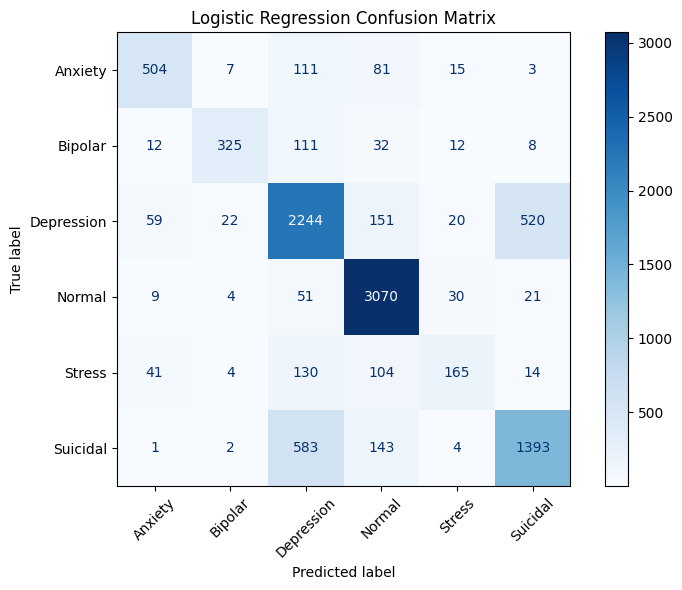


Assets saved successfully.


{'model': LogisticRegression(max_iter=1000, random_state=42),
 'predictions': array(['Anxiety', 'Normal', 'Normal', ..., 'Normal', 'Depression',
        'Depression'], dtype=object),
 'metrics': {'Model': 'Logistic Regression',
  'Accuracy': 0.7696382170697581,
  'Precision': 0.7667093486386863,
  'Recall': 0.7696382170697581,
  'Weighted F1': 0.7633193739063863,
  'Macro F1': 0.7129033691613355,
  'Train Time (s)': 19.292922258377075,
  'Inference Time (s)': 0.010369300842285156}}

In [24]:
# Train and evaluate Logistic Regression

evaluate_model(
    model=log_reg,
    model_name="Logistic Regression",
    X_train=X_train_tfidf,
    X_test=X_test_tfidf,
    y_train=y_train,
    y_test=y_test
)



---

## 2. Multinomial Naive Bayes

Multinomial Naive Bayes is one of the most widely used algorithms for text
classification. It estimates the probability of each class based on word
frequencies and assumes that features are conditionally independent.

Despite this simplifying assumption, the algorithm often delivers competitive
performance on sparse text representations such as TF-IDF while maintaining
very fast training and prediction times.

In [25]:
# Initialize the Multinomial Naive Bayes classifier

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

Multinomial Naive Bayes
Model               : Multinomial Naive Bayes
Accuracy            : 0.7028
Precision           : 0.7097
Recall              : 0.7028
Weighted F1         : 0.6872
Macro F1            : 0.5835
Train Time (s)      : 0.2006
Inference Time (s)  : 0.0118

              precision    recall  f1-score   support

     Anxiety       0.75      0.63      0.68       721
     Bipolar       0.88      0.44      0.59       500
  Depression       0.59      0.75      0.66      3016
      Normal       0.82      0.88      0.85      3185
      Stress       0.59      0.04      0.08       458
    Suicidal       0.69      0.60      0.64      2126

    accuracy                           0.70     10006
   macro avg       0.72      0.56      0.58     10006
weighted avg       0.71      0.70      0.69     10006



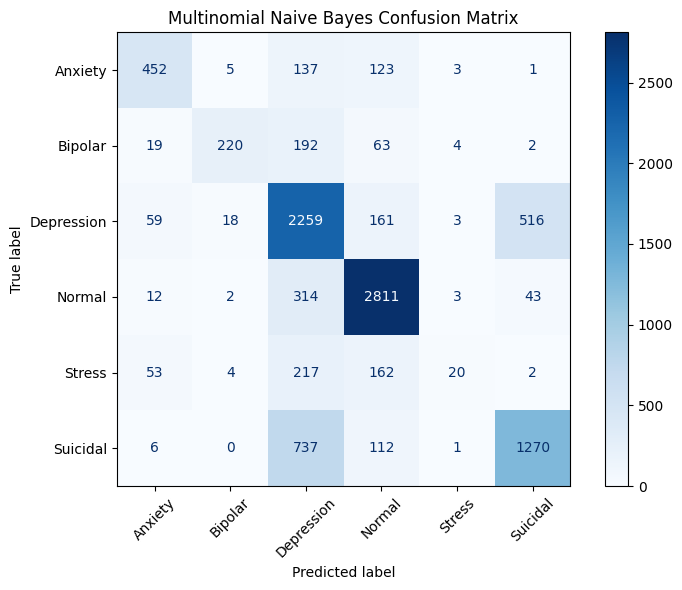


Assets saved successfully.


{'model': MultinomialNB(),
 'predictions': array(['Anxiety', 'Normal', 'Normal', ..., 'Normal', 'Depression',
        'Suicidal'], dtype='<U10'),
 'metrics': {'Model': 'Multinomial Naive Bayes',
  'Accuracy': 0.7027783330001999,
  'Precision': 0.7096960448758498,
  'Recall': 0.7027783330001999,
  'Weighted F1': 0.6872453982455892,
  'Macro F1': 0.5835095930920969,
  'Train Time (s)': 0.20063304901123047,
  'Inference Time (s)': 0.011763572692871094}}

In [26]:
# Train and evaluate the model

evaluate_model(

    model=nb_model,
    model_name="Multinomial Naive Bayes",
    X_train=X_train_tfidf,
    X_test=X_test_tfidf,
    y_train=y_train,
    y_test=y_test
)



---


## 3. Linear Support Vector Machine
(Linear SVM)

Support Vector Machine (SVM) is one of the most effective algorithms for text
classification. It performs particularly well with high-dimensional sparse
feature spaces such as TF-IDF.

Unlike probabilistic models, Linear SVM focuses on finding the optimal decision
boundary that maximizes the separation margin between classes, leading to
strong generalization performance.

Due to its effectiveness and efficiency, Linear SVM is widely used as a
benchmark model in many NLP classification tasks.

In [27]:
# Initialize the Linear SVM classifier

from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

Linear SVM
Model               : Linear SVM
Accuracy            : 0.7616
Precision           : 0.7565
Recall              : 0.7616
Weighted F1         : 0.7569
Macro F1            : 0.7103
Train Time (s)      : 15.5936
Inference Time (s)  : 0.0106

              precision    recall  f1-score   support

     Anxiety       0.77      0.72      0.75       721
     Bipolar       0.84      0.70      0.76       500
  Depression       0.69      0.71      0.70      3016
      Normal       0.87      0.95      0.91      3185
      Stress       0.61      0.39      0.47       458
    Suicidal       0.68      0.66      0.67      2126

    accuracy                           0.76     10006
   macro avg       0.74      0.69      0.71     10006
weighted avg       0.76      0.76      0.76     10006



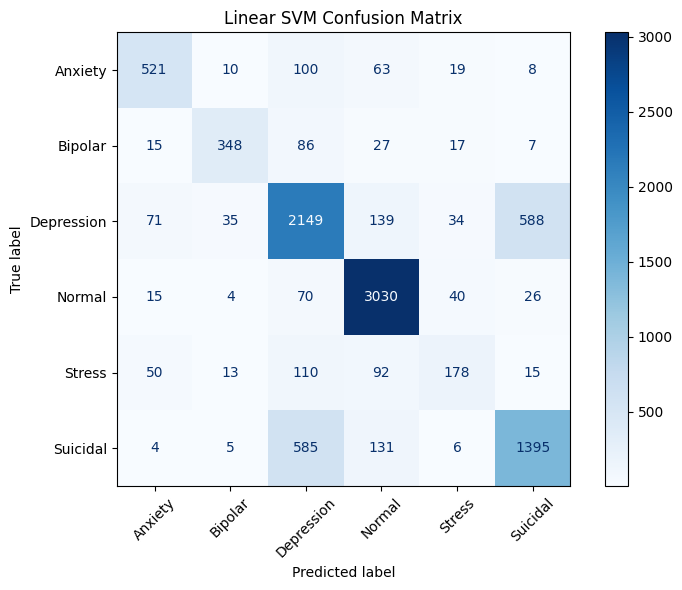


Assets saved successfully.


{'model': LinearSVC(random_state=42),
 'predictions': array(['Stress', 'Normal', 'Normal', ..., 'Normal', 'Depression',
        'Depression'], dtype=object),
 'metrics': {'Model': 'Linear SVM',
  'Accuracy': 0.7616430141914851,
  'Precision': 0.756455740510937,
  'Recall': 0.7616430141914851,
  'Weighted F1': 0.7569032124518695,
  'Macro F1': 0.7102522371820533,
  'Train Time (s)': 15.593565702438354,
  'Inference Time (s)': 0.010577678680419922}}

In [28]:
# Train and evaluate the model

evaluate_model(

    model=svm_model,
    model_name="Linear SVM",
    X_train=X_train_tfidf,
    X_test=X_test_tfidf,
    y_train=y_train,
    y_test=y_test
)



---

## 4. Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision
trees to improve prediction accuracy and reduce overfitting.

Unlike linear models, Random Forest can capture complex non-linear
relationships between features. Although tree-based models are generally less
common for sparse text representations such as TF-IDF, they are included in
this study to investigate whether ensemble learning can improve classification
performance.

## Model Configuration

The model is initialized with a larger number of trees to improve stability and
generalization.

A fixed random state is used to ensure reproducible results throughout the
experiments.

In [29]:
# Initialize the Random Forest classifier

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

Random Forest
Model               : Random Forest
Accuracy            : 0.6848
Precision           : 0.7161
Recall              : 0.6848
Weighted F1         : 0.6570
Macro F1            : 0.5208
Train Time (s)      : 456.7040
Inference Time (s)  : 1.2557

              precision    recall  f1-score   support

     Anxiety       0.88      0.41      0.56       721
     Bipolar       0.94      0.27      0.42       500
  Depression       0.55      0.80      0.65      3016
      Normal       0.82      0.95      0.88      3185
      Stress       0.70      0.03      0.06       458
    Suicidal       0.70      0.46      0.56      2126

    accuracy                           0.68     10006
   macro avg       0.76      0.49      0.52     10006
weighted avg       0.72      0.68      0.66     10006



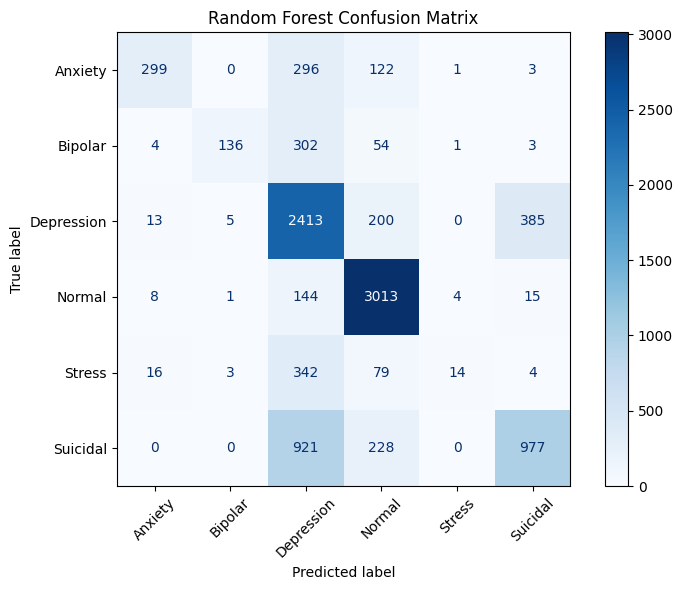


Assets saved successfully.


{'model': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
 'predictions': array(['Depression', 'Normal', 'Normal', ..., 'Normal', 'Depression',
        'Depression'], dtype=object),
 'metrics': {'Model': 'Random Forest',
  'Accuracy': 0.6847891265240855,
  'Precision': 0.7160568106059076,
  'Recall': 0.6847891265240855,
  'Weighted F1': 0.6569804355706221,
  'Macro F1': 0.5208410108128939,
  'Train Time (s)': 456.7040319442749,
  'Inference Time (s)': 1.255690097808838}}

In [30]:
# Train and evaluate the model

evaluate_model(

    model=rf_model,
    model_name="Random Forest",
    X_train=X_train_tfidf,
    X_test=X_test_tfidf,
    y_train=y_train,
    y_test=y_test
)

## 5. Extreme Gradient Boosting (XGBoost)

XGBoost is a powerful gradient boosting algorithm that builds an ensemble of
decision trees sequentially, where each new tree attempts to correct the
errors made by previous ones.

It is widely recognized for its high predictive performance and has been
successfully applied to many structured data problems. Although TF-IDF
representations are typically more suitable for linear models, XGBoost is
evaluated to determine whether boosted trees can capture additional patterns
within the text features.

## Model Configuration

The model is initialized with a balanced set of hyperparameters to establish a
strong baseline while avoiding unnecessary computational complexity.

Hyperparameter optimization will be performed later only if XGBoost proves to
be one of the top-performing models.

In [33]:
# Initialize the XGBoost classifier

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=1
)

## Label Encoding

XGBoost requires numerical target labels rather than categorical text labels.

Therefore, the target classes are encoded into integer values while preserving
the mapping between each label and its corresponding encoded representation.

In [34]:
# Encode target labels for XGBoost

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_test_encoded = label_encoder.transform(y_test)

In [37]:
from pathlib import Path

joblib.dump(

    label_encoder,
    ENCODERS_DIR / "label_encoder.pkl"
)
print("Label encoder saved successfully.")

Label encoder saved successfully.


XGBoost
Model               : XGBoost
Accuracy            : 0.7662
Precision           : 0.7631
Recall              : 0.7662
Weighted F1         : 0.7630
Macro F1            : 0.7236
Train Time (s)      : 818.1059
Inference Time (s)  : 0.3023

              precision    recall  f1-score   support

           0       0.77      0.73      0.75       721
           1       0.87      0.69      0.77       500
           2       0.69      0.72      0.71      3016
           3       0.88      0.95      0.91      3185
           4       0.63      0.47      0.54       458
           5       0.69      0.66      0.67      2126

    accuracy                           0.77     10006
   macro avg       0.75      0.70      0.72     10006
weighted avg       0.76      0.77      0.76     10006



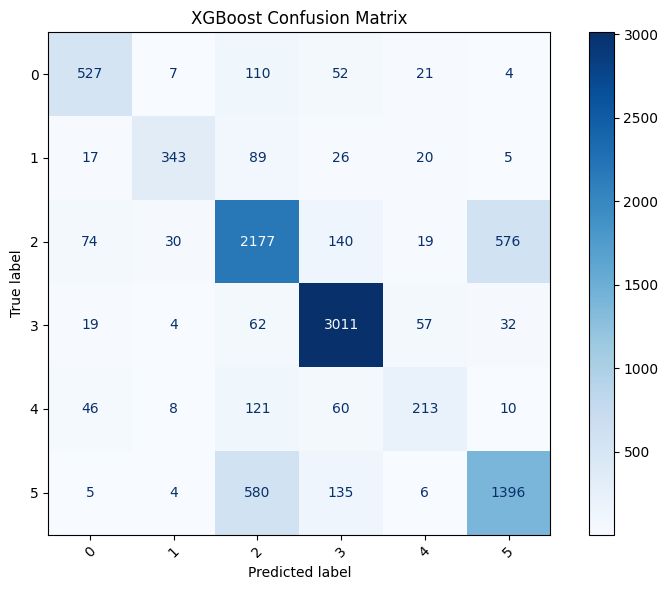


Assets saved successfully.


{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=1,
               num_parallel_tree=None, ...),
 'predictions': array([0, 3, 3, ..., 3, 2, 2]),
 'metrics': {'Model': 'XGBoost',
  'Accuracy': 0.7662402558464921,
  'Precision': 0.7630719320745573,
  'Recall': 0.7662402558464921,
  'Weighted F1': 0.

In [38]:
evaluate_model(

    model=xgb_model,
    model_name="XGBoost",
    X_train=X_train_tfidf,
    X_test=X_test_tfidf,
    y_train=y_train_encoded,
    y_test=y_test_encoded
)

# ==============================================================================
# Machine Learning Model Comparison

In this section, all evaluated machine learning models are compared using
multiple evaluation metrics to identify the most suitable model for the text
classification task.

The comparison considers predictive performance, computational efficiency,
and the ability to generalize across different classes. The selected model
will then be optimized through hyperparameter tuning before proceeding to
deep learning approaches.

## Model Ranking Strategy

Because the dataset is imbalanced, models are ranked according to their
Weighted F1-score rather than accuracy.

Weighted F1 provides a more reliable assessment by jointly considering
precision and recall while accounting for the support of each class.

Accuracy, Macro F1-score, and computational efficiency are reported as
complementary evaluation metrics.

In [39]:
# Create Performance Summary Table

results_df = (
    pd.DataFrame(results)
    .sort_values(by="Weighted F1", ascending=False)
    .reset_index(drop=True)
)

results_df.insert(0, "Rank", range(1, len(results_df) + 1))

results_df

,Rank,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Train Time (s),Inference Time (s)
0,1,Logistic Regression,0.769638,0.766709,0.769638,0.763319,0.712903,19.292922,0.010369
1,2,XGBoost,0.766240,0.763072,0.766240,0.762957,0.723617,818.105881,0.302258
2,3,Linear SVM,0.761643,0.756456,0.761643,0.756903,0.710252,15.593566,0.010578
3,4,Multinomial Naive Bayes,0.702778,0.709696,0.702778,0.687245,0.583510,0.200633,0.011764
4,5,Random Forest,0.684789,0.716057,0.684789,0.656980,0.520841,456.704032,1.255690


In [40]:
results_df.style.highlight_max(
    subset=[
        "Accuracy",
        "Weighted F1",
        "Macro F1"
    ],
    color="lightgreen"
).highlight_min(
    subset=[
        "Train Time (s)",
        "Inference Time (s)"
    ],
    color="lightblue"
)

,Rank,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Train Time (s),Inference Time (s)
0,1,Logistic Regression,0.769638,0.766709,0.769638,0.763319,0.712903,19.292922,0.010369
1,2,XGBoost,0.766240,0.763072,0.766240,0.762957,0.723617,818.105881,0.302258
2,3,Linear SVM,0.761643,0.756456,0.761643,0.756903,0.710252,15.593566,0.010578
3,4,Multinomial Naive Bayes,0.702778,0.709696,0.702778,0.687245,0.583510,0.200633,0.011764
4,5,Random Forest,0.684789,0.716057,0.684789,0.656980,0.520841,456.704032,1.255690


In [41]:
joblib.dump(

    results_df,
    RESULTS_DIR / "baseline_models_summary.pkl"
)

['/content/drive/MyDrive/Mental_Health_Classification/results/baseline_models_summary.pkl']

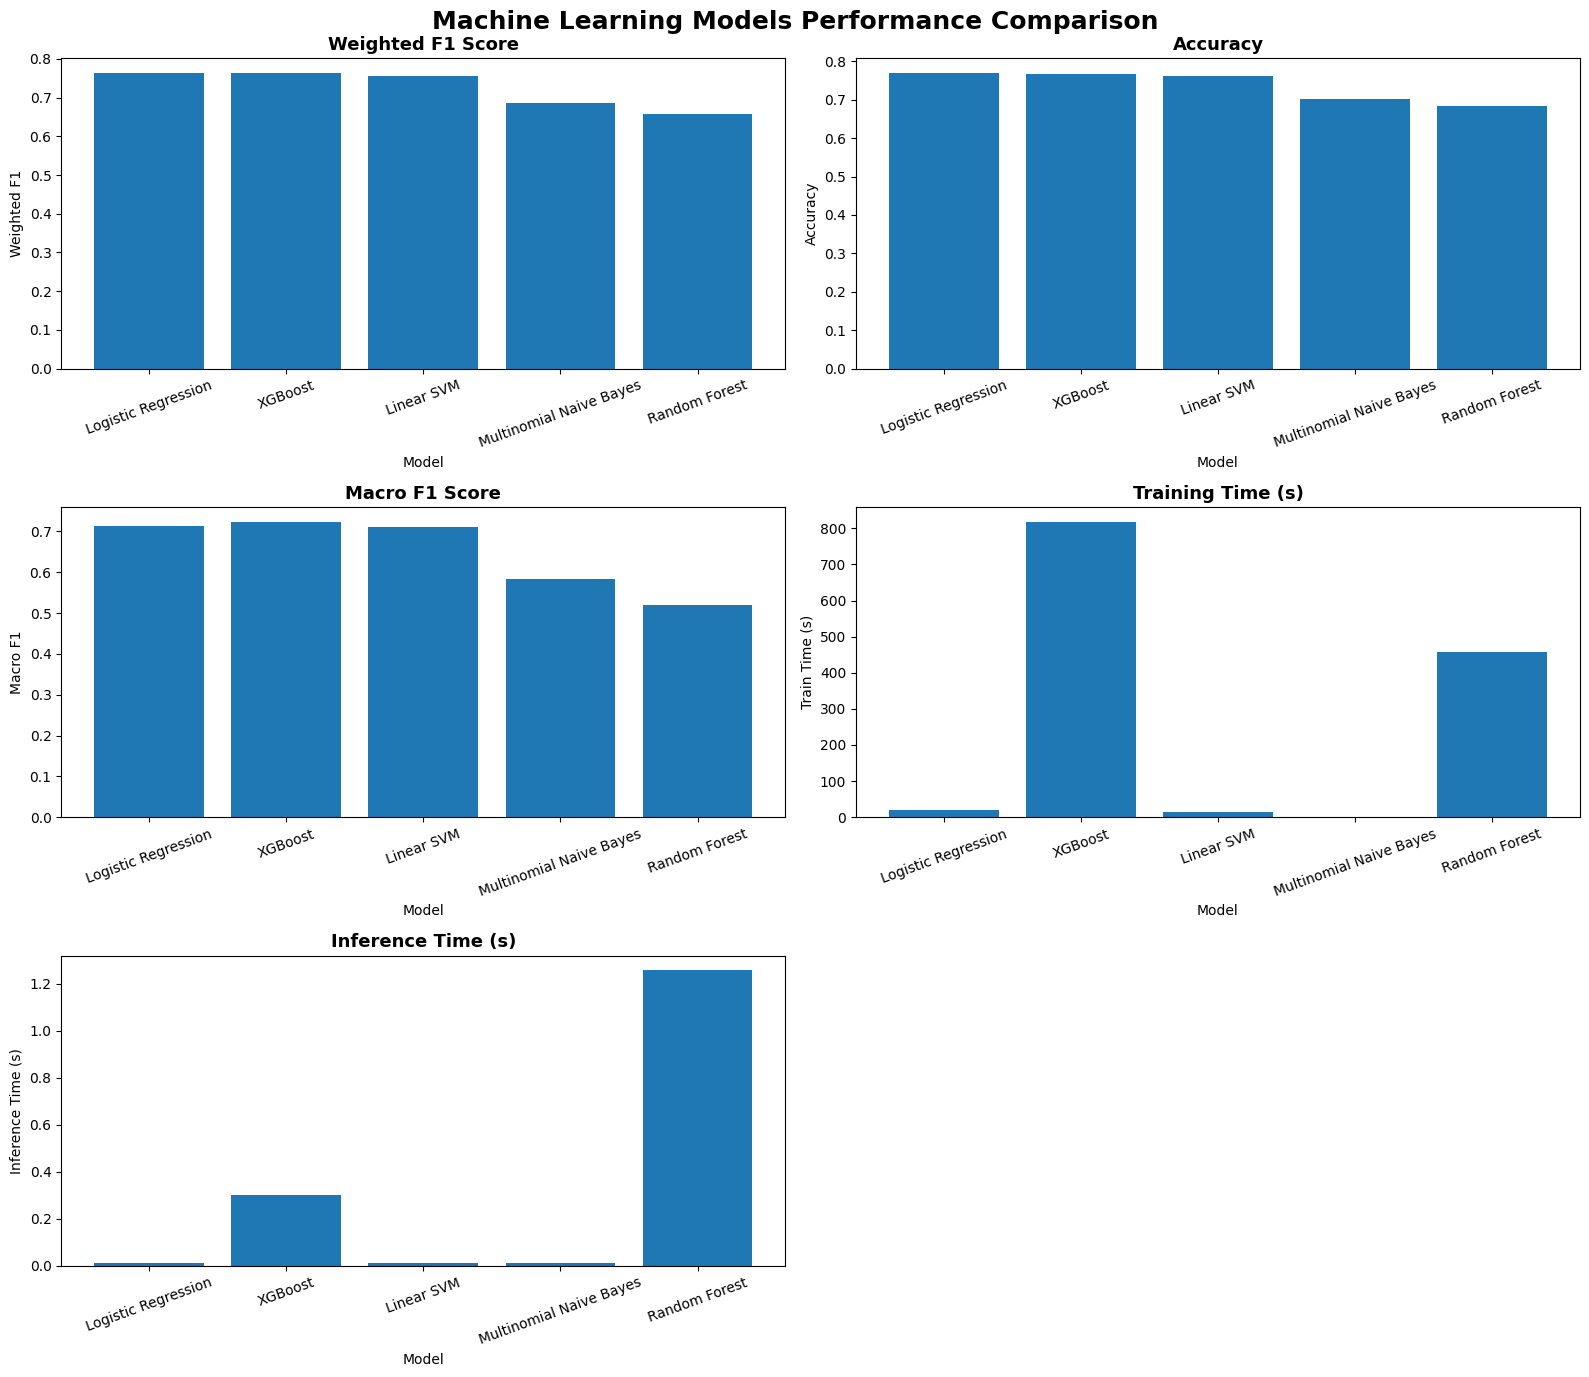

In [42]:
# Create a comprehensive comparison dashboard

metrics = [

    ("Weighted F1", "Weighted F1 Score"),

    ("Accuracy", "Accuracy"),

    ("Macro F1", "Macro F1 Score"),

    ("Train Time (s)", "Training Time (s)"),

    ("Inference Time (s)", "Inference Time (s)")
]

fig, axes = plt.subplots(

    3,

    2,

    figsize=(16, 14)

)

axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics):

    ax.bar(

        results_df["Model"],

        results_df[metric]

    )

    ax.set_title(

        title,

        fontsize=13,

        weight="bold"

    )

    ax.set_xlabel("Model")

    ax.set_ylabel(metric)

    ax.tick_params(

        axis="x",

        rotation=20

    )

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.suptitle(

    "Machine Learning Models Performance Comparison",

    fontsize=18,

    weight="bold"

)

plt.tight_layout()

plt.savefig(

    FIGURES_DIR / "ml_models_comparison_dashboard.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Overall Discussion

The experimental results demonstrate that different machine learning algorithms exhibit distinct trade-offs between predictive performance and computational efficiency.

Among all evaluated models, Logistic Regression achieved the highest Accuracy (76.96%) and Weighted F1-score (76.33%), while maintaining a relatively short training time of approximately 19 seconds. These results confirm that linear models remain highly effective for high-dimensional sparse TF-IDF representations commonly used in text classification tasks.

XGBoost produced competitive performance, achieving the highest Macro F1-score (72.36%), indicating slightly better balanced performance across minority classes. However, this improvement came at a substantial computational cost, requiring more than 818 seconds for training—over forty times longer than Logistic Regression.

Linear SVM also demonstrated strong predictive performance with results close to those of Logistic Regression, making it another competitive baseline for sparse text classification. Nevertheless, its overall performance remained slightly lower across the primary evaluation metrics.

In contrast, Multinomial Naive Bayes and Random Forest achieved noticeably lower classification performance. Although Naive Bayes trained extremely quickly, its lower F1-scores indicate limited capability to capture the complexity of the mental health text dataset. Random Forest required a long training time while producing the weakest overall predictive performance, making it less suitable for TF-IDF-based text classification.

Overall, the experiments demonstrate that linear models consistently outperform tree-based ensemble methods on sparse TF-IDF features, providing an excellent balance between predictive accuracy and computational efficiency.

## Model Selection

Considering the evaluation metrics collectively, Weighted F1-score was selected as the primary criterion for ranking the machine learning models because the dataset is moderately imbalanced across the seven mental health classes. Unlike accuracy, the Weighted F1-score considers both precision and recall while accounting for class frequencies, providing a more reliable measure of overall classification performance.

Based on this criterion, Logistic Regression was selected as the best-performing classical machine learning model. It achieved the highest Weighted F1-score and Accuracy while requiring only a fraction of the computational time needed by XGBoost.

Although XGBoost obtained a slightly higher Macro F1-score, the improvement for minority classes was relatively small compared with its significantly higher training cost. Therefore, the additional computational complexity was not justified for this application.

Consequently, Logistic Regression was chosen as the final baseline machine learning model and will serve as the reference for subsequent comparisons with the deep learning models (LSTM, BiLSTM) and the transformer-based DeBERTa model.

# ==============================================================================
# Hyperparameter Optimization (Logistic Regression)

The baseline experiments identified Logistic Regression as the most suitable
classical machine learning model after considering both predictive performance
and computational efficiency.

In this section, hyperparameter optimization is performed to further improve
its generalization capability by exploring different combinations of
regularization strategies and optimization parameters.

Since Logistic Regression has a relatively small hyperparameter search space,
GridSearchCV is employed to exhaustively evaluate all candidate
configurations.

## Why GridSearchCV?

Hyperparameter optimization aims to identify the best combination of model
parameters that maximizes predictive performance.

Unlike models with very large search spaces, Logistic Regression has only a
small number of influential hyperparameters. Therefore, GridSearchCV is an
appropriate choice because it evaluates every possible parameter combination,
ensuring that the optimal configuration is identified.

In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:
# Hyperparameter Search Space

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "saga"],
    "class_weight": [None, "balanced"],
    "max_iter": [1000]
}

## Hyperparameter Optimization

GridSearchCV evaluates every parameter combination using cross-validation.

The optimal configuration is selected according to the weighted F1-score,
which provides a balanced evaluation for this multi-class imbalanced
classification problem.

In [45]:
# Grid Search

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [46]:
# Perform Hyperparameter Optimization

grid_search.fit(
    X_train_tfidf,
    y_train
)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'class_weight': [None, 'balanced'], 'max_iter': [1000],
                         'solver': ['lbfgs', 'saga']},
             scoring='f1_weighted', verbose=2)

In [47]:
# Best Parameters

print("Best Parameters:\n")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:

{'C': 1, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'lbfgs'}

Best Cross Validation Score:
0.7629566018920396


In [48]:
joblib.dump(
    grid_search,
    RESULTS_DIR / "logistic_grid_search.pkl"
)

['/content/drive/MyDrive/Mental_Health_Classification/results/logistic_grid_search.pkl']

## Evaluate the Optimized Model

The optimized model is evaluated using the same reusable evaluation function employed throughout this notebook. This ensures consistency while automatically saving the trained model, prediction pipeline, and evaluation metrics.

LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42)
Optimized Logistic Regression
Model               : Optimized Logistic Regression
Accuracy            : 0.7663
Precision           : 0.7764
Recall              : 0.7663
Weighted F1         : 0.7668
Macro F1            : 0.7329
Train Time (s)      : 21.8517
Inference Time (s)  : 0.0227

              precision    recall  f1-score   support

     Anxiety       0.74      0.81      0.77       721
     Bipolar       0.73      0.78      0.76       500
  Depression       0.78      0.62      0.69      3016
      Normal       0.90      0.92      0.91      3185
      Stress       0.46      0.73      0.56       458
    Suicidal       0.68      0.73      0.71      2126

    accuracy                           0.77     10006
   macro avg       0.71      0.77      0.73     10006
weighted avg       0.78      0.77      0.77     10006



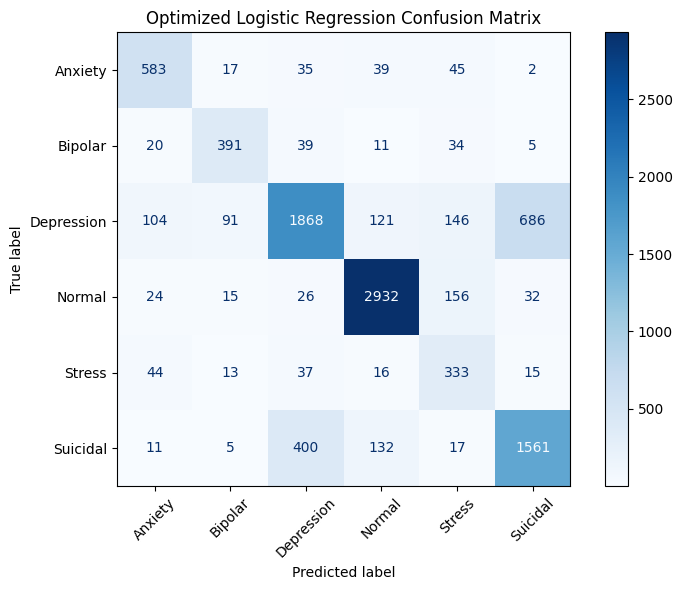


Assets saved successfully.


In [50]:
# Best Model

best_logistic = grid_search.best_estimator_

print(best_logistic)

optimized_results = evaluate_model(

    model=best_logistic,
    model_name="Optimized Logistic Regression",
    X_train=X_train_tfidf,
    X_test=X_test_tfidf,
    y_train=y_train,
    y_test=y_test
)

In [51]:
joblib.dump(
    best_logistic,
    f"{PROJECT_DIR}/models/tuned_logistic_regression.pkl"
)

print("Optimized Logistic Regression saved successfully.")

Optimized Logistic Regression saved successfully.


## Baseline vs Optimized Logistic Regression

The following comparison illustrates the effect of hyperparameter optimization
on the performance of Logistic Regression.

The results indicate whether tuning provides measurable improvements over the
baseline configuration.

In [52]:
optimized_metrics = optimized_results["metrics"]

comparison = pd.DataFrame({

    "Version":[

        "Baseline Logistic Regression",
        "Optimized Logistic Regression"
    ],

    "Accuracy":[

        results_df.loc[
            results_df["Model"]=="Logistic Regression",
            "Accuracy"
        ].iloc[0],

        optimized_metrics["Accuracy"]
    ],

    "Weighted F1":[

        results_df.loc[
            results_df["Model"]=="Logistic Regression",
            "Weighted F1"
        ].iloc[0],

        optimized_metrics["Weighted F1"]
    ],

    "Macro F1":[

        results_df.loc[
            results_df["Model"]=="Logistic Regression",
            "Macro F1"
        ].iloc[0],

        optimized_metrics["Macro F1"]
    ]
})

comparison

,Version,Accuracy,Weighted F1,Macro F1
0,Baseline Logistic Regression,0.769638,0.763319,0.712903
1,Optimized Logistic Regression,0.766340,0.766844,0.732854


Although hyperparameter optimization slightly improved the weighted F1-score, it also resulted in a small reduction in overall accuracy. Considering the overall balance between predictive performance, computational efficiency, and simplicity, the baseline Logistic Regression model was retained as the final classical machine learning model.

In [53]:
# Save Hyperparameter Search Results

comparison.to_csv(

    RESULTS_DIR / "logistic_tuning_comparison.csv",

    index=False

)

best_params = pd.DataFrame(

    [grid_search.best_params_]

)

best_params.to_csv(

    RESULTS_DIR / "best_logistic_parameters.csv",

    index=False

)

print("Hyperparameter optimization results saved successfully.")

Hyperparameter optimization results saved successfully.
